In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/gurgaon_properties_outlier_treated_1_1.csv')

In [5]:
pd.set_option('display.max_columns',None)

In [16]:
df.shape

(3688, 24)

In [6]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area-room_ratio
0,house,bestech park view aindependentda,sector 81,4.35,7937.0,5481.0,Plot area 5480(509.11 sq.m.),4,4,3,2.0,North,Relatively New,NaN,5480.0,NaN,0,1,1,0,0,0,51,1370.250000
1,flat,signature global solera,sector 107,0.28,5680.0,493.0,Carpet area: 489 (45.43 sq.m.),2,2,2,6.0,West,Relatively New,NaN,NaN,489.0,0,0,0,0,0,0,45,246.500000
2,flat,hcbs sports ville,sohna road,0.29,5588.0,519.0,Carpet area: 519 (48.22 sq.m.),2,2,1,4.0,NaN,Relatively New,NaN,NaN,519.0,0,0,0,0,0,0,44,259.500000
3,flat,orchid petals,sector 49,2.55,12319.0,2070.0,Super Built up area 2070(192.31 sq.m.)Built Up...,3,4,3,8.0,East,Relatively New,2070.0,2060.0,1760.0,1,0,0,0,0,1,49,690.000000
4,house,signature global city,sector 37d,1.27,8089.0,1570.0,Plot area 1570(145.86 sq.m.),3,3,3,4.0,East,Under Construction,NaN,1570.0,NaN,0,0,0,1,0,0,89,523.333333


In [8]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


bulid up area

<Axes: xlabel='built_up_area', ylabel='super_built_up_area'>

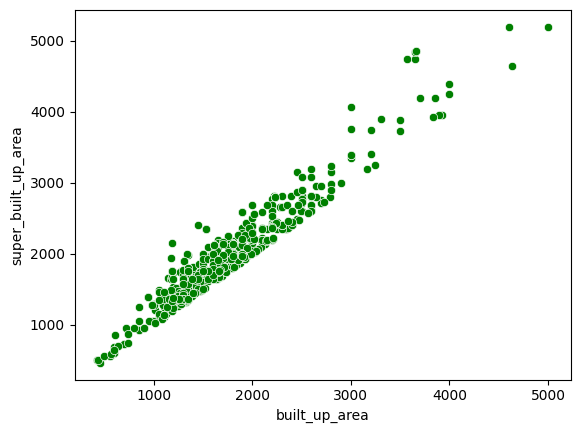

In [11]:
sns.scatterplot(x=df['built_up_area'], y=df['super_built_up_area'],color='green')

<Axes: xlabel='built_up_area', ylabel='carpet_area'>

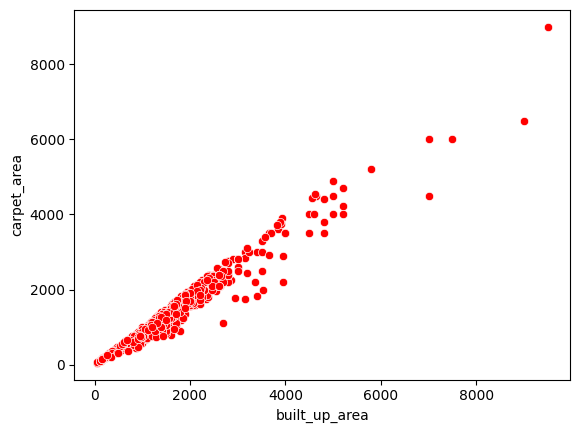

In [13]:
sns.scatterplot(x=df['built_up_area'],y=df['carpet_area'],color='red')

In [18]:
all_present_df = df[~((df['super_built_up_area'].isnull()) | (df['built_up_area'].isnull()) | (df['carpet_area'].isnull()))]

In [19]:
all_present_df.shape

(534, 24)

In [20]:
super_to_built_up_ratio = (all_present_df['super_built_up_area']/all_present_df['built_up_area']).median()

In [21]:
carpet_to_built_up_ratio = (all_present_df['carpet_area']/all_present_df['built_up_area']).median()

In [22]:
print(super_to_built_up_ratio, carpet_to_built_up_ratio)

1.1048701298701298 0.900140056022409


In [23]:
# both present built up null
sbc_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [26]:
sbc_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area-room_ratio
36,flat,emaar palm gardens,sector 83,1.75,9211.0,1900.0,Super Built up area 1900(176.52 sq.m.)Carpet a...,3,3,3+,11.0,East,Relatively New,1900.0,NaN,1240.04,0,1,0,0,0,0,120,633.333333
37,flat,dlf the primus,sector 82a,2.85,10936.0,2606.0,Super Built up area 2606(242.11 sq.m.)Carpet a...,4,4,3+,2.0,North-East,New Property,2606.0,NaN,1800.00,0,1,0,0,0,2,174,651.500000
61,flat,ireo the corridors,sector 67a,1.70,9844.0,1727.0,Super Built up area 1727(160.44 sq.m.)Carpet a...,3,3,2,10.0,North-East,New Property,1727.0,NaN,1017.00,0,1,0,0,1,1,44,575.666667
71,flat,emaar gurgaon greens,sector 102,1.50,9091.0,1650.0,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,7.0,West,Relatively New,1650.0,NaN,1022.58,0,0,0,1,0,1,174,550.000000
82,flat,dlf regal gardens,sector 90,1.25,10417.0,1200.0,Super Built up area 1702(158.12 sq.m.)Carpet a...,3,3,3,18.0,North,Moderately Old,1702.0,NaN,1200.00,0,1,0,0,0,0,100,400.000000


In [27]:
sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)

/tmp/ipykernel_6693/1215074969.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sbc_df['built_up_area'].fillna(round(((sbc_df['super_built_up_area']/1.105) + (sbc_df['carpet_area']/0.9))/2),inplace=True)
/tmp/ipykernel_6693/1215074969.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sbc_df['built_up_area'].fillna(round(((sbc_df['super_bu

In [28]:
df.update(sbc_df)

In [29]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [30]:
# sb present c is null built up null
sb_df = df[~(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & (df['carpet_area'].isnull())]

In [31]:
sb_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area-room_ratio
21,flat,paras quartier,gwal pahari,7.50,14019.0,5350.0,Super Built up area 5350(497.03 sq.m.),4,4,3+,20.0,North-East,New Property,5350.0,NaN,NaN,0,1,0,1,1,1,49,1337.500000
22,flat,bestech park view residency,sector 2,1.40,7865.0,1780.0,Super Built up area 1780(165.37 sq.m.),3,3,3+,8.0,South-West,Moderately Old,1780.0,NaN,NaN,0,0,0,0,0,0,92,593.333333
23,flat,.,gwal pahari,7.00,10999.0,6364.0,Super Built up area 6000(557.42 sq.m.),4,4,3+,6.0,South-West,Relatively New,6000.0,NaN,NaN,0,1,0,0,0,0,52,1591.000000
28,flat,ats kocoon,sector 109,1.68,9628.0,1745.0,Super Built up area 1745(162.12 sq.m.),3,3,3,8.0,North-East,Relatively New,1745.0,NaN,NaN,0,0,0,0,0,0,142,581.666667
29,flat,city shri ram apartments 1,sector 110,0.22,3667.0,600.0,Super Built up area 600(55.74 sq.m.),2,1,1,1.0,NaN,Relatively New,600.0,NaN,NaN,0,0,0,0,0,0,0,300.000000


In [32]:
sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)

/tmp/ipykernel_6693/1714170073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)
/tmp/ipykernel_6693/1714170073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sb_df['built_up_area'].fillna(round(sb_df['super_built_up_area']/1.105),inplace=True)


In [33]:
df.update(sb_df)

In [34]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


In [35]:
# sb null c is present built up null
c_df = df[(df['super_built_up_area'].isnull()) & (df['built_up_area'].isnull()) & ~(df['carpet_area'].isnull())]

In [36]:
c_df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score,area-room_ratio
1,flat,signature global solera,sector 107,0.28,5680.0,493.0,Carpet area: 489 (45.43 sq.m.),2,2,2,6.0,West,Relatively New,NaN,NaN,489.0,0,0,0,0,0,0,45,246.500000
2,flat,hcbs sports ville,sohna road,0.29,5588.0,519.0,Carpet area: 519 (48.22 sq.m.),2,2,1,4.0,NaN,Relatively New,NaN,NaN,519.0,0,0,0,0,0,0,44,259.500000
6,flat,pyramid urban,sector 67a,0.56,7932.0,706.0,Carpet area: 700 (65.03 sq.m.),2,2,2,0.0,North-East,Relatively New,NaN,NaN,700.0,0,0,0,0,1,0,49,353.000000
10,flat,signature global solera,sector 107,0.50,7752.0,645.0,Carpet area: 645 (59.92 sq.m.),3,2,2,6.0,South-East,Relatively New,NaN,NaN,645.0,0,0,0,0,1,0,15,215.000000
17,flat,sare homes,sector 92,0.80,5253.0,1523.0,Carpet area: 1523 (141.49 sq.m.),3,3,3,7.0,North-West,Relatively New,NaN,NaN,1523.0,1,0,0,0,0,1,80,507.666667


In [37]:
c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)

/tmp/ipykernel_6693/2136919732.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)
/tmp/ipykernel_6693/2136919732.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  c_df['built_up_area'].fillna(round(c_df['carpet_area']/0.9),inplace=True)


In [38]:
df.update(c_df)

In [39]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
area,0
areaWithType,0
bedRoom,0
bathroom,0
balcony,0


<Axes: xlabel='built_up_area', ylabel='price'>

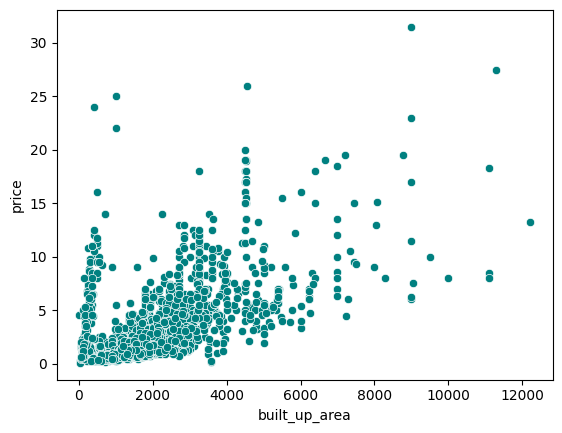

In [41]:
sns.scatterplot(x=df['built_up_area'],y=df['price'],color='teal')

In [42]:
anamoly_df = df[(df['built_up_area'] < 2000) & (df['price'] > 2.5)][['price','area','built_up_area']]

In [43]:
anamoly_df.head()

,price,area,built_up_area
7,7.25,2471.0,303.0
14,3.15,1548.0,1548.0
15,3.80,1458.0,162.0
25,4.00,1836.0,1836.0
42,4.85,1607.0,1785.0


In [44]:
anamoly_df['built_up_area'] = anamoly_df['area']

In [45]:
df.update(anamoly_df)

<Axes: xlabel='built_up_area', ylabel='price'>

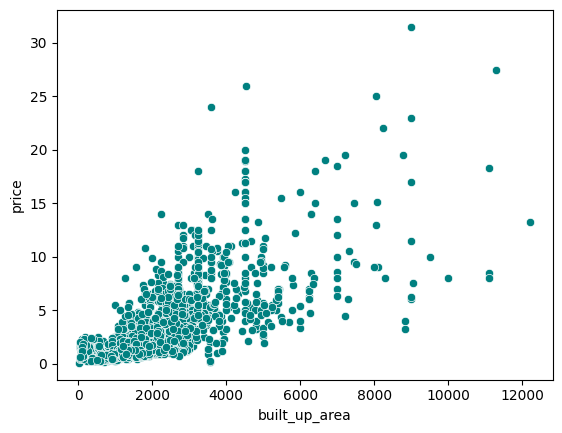

In [47]:
sns.scatterplot(x=df['built_up_area'],y=df['price'],color='teal')

In [49]:
df.drop(columns=['area','areaWithType','super_built_up_area','carpet_area','area-room_ratio'],inplace=True)

In [50]:
df.sample(5)

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
654,flat,conscient heritage max,sector 102,1.78,9218.0,3,4,3+,5.0,East,Moderately Old,1748.0,0,1,0,0,0,0,125
1484,flat,m3m merlin,sector 67,3.40,14419.0,3,4,3,16.0,North-West,Relatively New,2016.0,0,1,0,0,0,1,174
1902,flat,dlf the primus,sector 82a,2.60,11439.0,4,4,3+,2.0,East,Relatively New,2273.0,0,0,0,0,1,0,38
2224,flat,green campus chs,manesar,0.90,3935.0,3,3,3+,6.0,North-East,Moderately Old,2070.0,0,1,0,0,0,0,5
2786,flat,ireo skyon,sector 60,2.50,16129.0,2,3,2,4.0,North-West,Relatively New,1403.0,1,0,0,0,0,0,100


In [51]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,17
facing,1074


floornum

In [52]:
df[df['floorNum'].isnull()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,facing,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
67,house,ansal sushant lok,sector 43,10.50,27911.0,4,4,2,NaN,North-East,Old Property,3762.0,0,1,0,0,0,0,59
407,house,independent,sector 7,6.50,15046.0,3,2,3+,NaN,NaN,Old Property,4320.0,0,0,0,0,0,0,9
600,flat,experion heartsong,dwarka expressway,1.08,6150.0,3,3,0,NaN,NaN,Under Construction,1758.0,0,0,0,0,0,0,0
653,house,jacob pura,sector 12,0.35,9722.0,2,1,0,NaN,NaN,Old Property,360.0,0,0,0,0,0,0,0
666,house,ansal sushant lok plots,sector 43,3.30,26570.0,1,1,0,NaN,NaN,Under Construction,1242.0,0,0,0,0,0,0,0
856,house,independent,sector 2,5.60,17284.0,8,6,3+,NaN,South-West,Moderately Old,3240.0,1,1,1,1,0,0,0
913,house,independent,sector 3,1.50,10288.0,3,3,0,NaN,NaN,Old Property,210.0,0,0,0,0,0,0,0
1096,house,dlf new town heights,sector 86,2.47,7719.0,4,4,3+,NaN,West,Moderately Old,2800.0,0,1,0,1,0,1,130
1374,house,vipul tatvam villa,sector 48,8.50,26235.0,4,4,1,NaN,NaN,Relatively New,3240.0,0,0,0,0,0,0,21
1700,house,independent,sector 24,1.45,2984.0,3,3,1,NaN,NaN,Old Property,540.0,0,0,0,0,0,0,9


In [53]:
df[df['property_type'] == 'house']['floorNum'].median()

2.0

In [54]:
df['floorNum'].fillna(2.0,inplace=True)

/tmp/ipykernel_6693/15612474.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['floorNum'].fillna(2.0,inplace=True)


In [55]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
facing,1074


In [56]:
1074/df.shape[0]

0.29121475054229934

facing

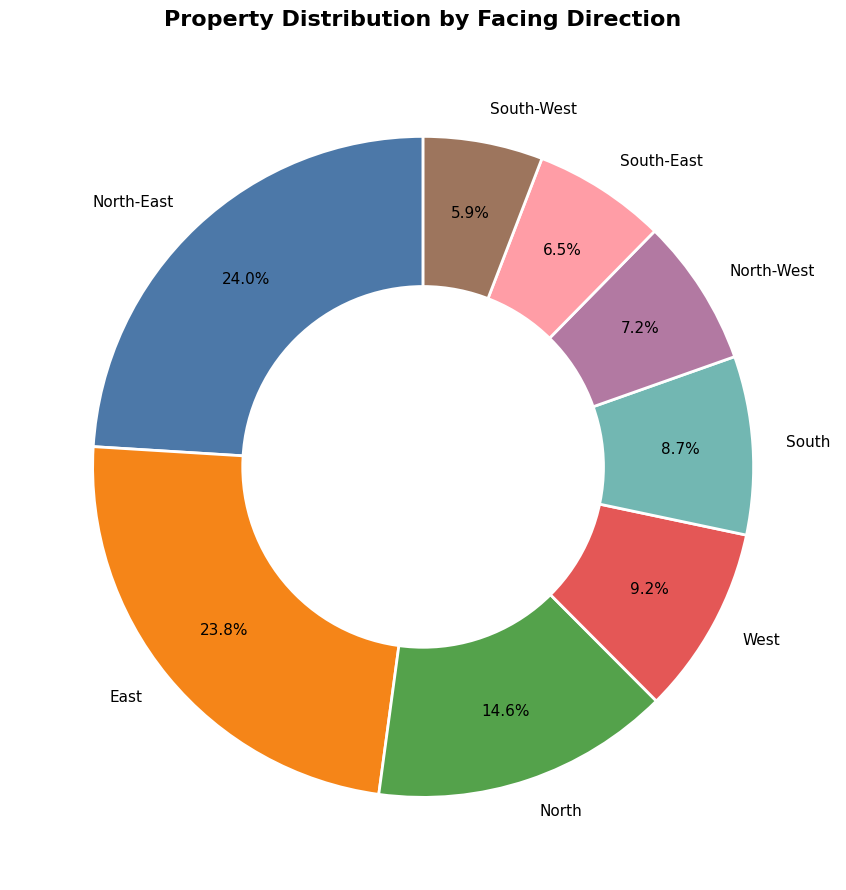

In [58]:
facing_counts = df['facing'].value_counts()
plt.figure(figsize=(9, 9))
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756','#72B7B2', '#B279A2', '#FF9DA6', '#9D755D']
plt.pie(facing_counts,labels=facing_counts.index,autopct='%1.1f%%',startangle=90,colors=colors,pctdistance=0.78,wedgeprops={'edgecolor': 'white', 'linewidth': 2},textprops={'fontsize': 11})
# Make it a donut chart
centre_circle = plt.Circle((0, 0), 0.55, fc='white')
plt.gca().add_artist(centre_circle)
plt.title('Property Distribution by Facing Direction',fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [59]:
df.drop(columns=['facing'],inplace=True)

In [60]:
df.isnull().sum()

,0
property_type,0
society,1
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [65]:
df[df['society'].isna()]

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1808,flat,NaN,sector 78,0.6,3692.0,2,2,0,2.0,Under Construction,1625.0,0,0,0,0,0,0,0


In [66]:
df.drop(index=[1808],inplace=True)

In [67]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


agePossession

In [68]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1635
New Property,591
Moderately Old,559
Undefined,320
Old Property,302
Under Construction,280


In [69]:
df[df['agePossession'] == 'Undefined']

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
13,flat,sare green parc,sector 92,0.85,6741.0,3,2,2,14.0,Undefined,1261.0,0,0,0,0,0,0,0
34,flat,sidhartha ncr one phase,sector 95,0.46,4646.0,2,2,0,6.0,Undefined,990.0,0,0,0,0,0,0,0
39,house,ansals palam vihar,sector 2,5.00,12500.0,6,4,0,3.0,Undefined,4000.0,0,0,0,0,0,0,0
76,flat,imperia the esfera,sector 37c,0.90,6272.0,3,3,3,9.0,Undefined,1435.0,0,0,0,0,0,0,66
85,flat,sapphire eighty three,sector 83,0.65,9286.0,1,1,0,6.0,Undefined,700.0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3622,flat,elevate,sector 50,6.75,19882.0,4,4,0,10.0,Undefined,3395.0,0,0,0,0,0,0,0
3645,house,independent,sector 69,0.80,10485.0,1,1,0,1.0,Undefined,763.0,0,0,0,0,0,0,0
3648,house,independent,sector 28,4.50,13889.0,4,4,0,4.0,Undefined,3240.0,0,0,0,0,0,0,0
3661,flat,housing apna enclave,sector 4,0.39,4105.0,2,2,1,1.0,Undefined,950.0,0,0,0,0,0,0,0


In [70]:
def mode_based_imputation(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector']) & (df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [71]:
df['agePossession'] = df.apply(mode_based_imputation,axis=1)

In [72]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1764
New Property,632
Moderately Old,602
Old Property,336
Under Construction,297
Undefined,56


In [73]:
def mode_based_imputation2(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['sector'] == row['sector'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [74]:
df['agePossession'] = df.apply(mode_based_imputation2,axis=1)

In [75]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1773
New Property,633
Moderately Old,609
Old Property,342
Under Construction,297
Undefined,33


In [76]:
def mode_based_imputation3(row):
    if row['agePossession'] == 'Undefined':
        mode_value = df[(df['property_type'] == row['property_type'])]['agePossession'].mode()
        # If mode_value is empty (no mode found), return NaN, otherwise return the mode
        if not mode_value.empty:
            return mode_value.iloc[0]
        else:
            return np.nan
    else:
        return row['agePossession']

In [77]:
df['agePossession'] = df.apply(mode_based_imputation3,axis=1)

In [78]:
df['agePossession'].value_counts()

,count
agePossession,
Relatively New,1775
Moderately Old,640
New Property,633
Old Property,342
Under Construction,297


In [79]:
df.isnull().sum()

,0
property_type,0
society,0
sector,0
price,0
price_per_sqft,0
bedRoom,0
bathroom,0
balcony,0
floorNum,0
agePossession,0


In [80]:
df.to_csv('gurgaon_properties_missing_value_imputation.csv',index=False)

In [81]:
df.shape

(3687, 18)